## House Price Prediction Model (Using Linear Regression)

In [1]:
# Importing useful libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [2]:
# loading the dataset

df=pd.read_csv('train.csv')
print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
# Finding the Null Values

df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [6]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
df.shape

(1460, 81)

In [8]:
print(df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [9]:
df.isnull()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1456,False,False,False,False,False,False,True,False,False,False,...,False,True,False,True,False,False,False,False,False,False
1457,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1458,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False


In [10]:
#There are columns with numeric datatype as well as object datatype containing null values so will fill numeric columns value by column mean and non-numeric  columns null values using string 'Unknown'

numeric_columns=df.select_dtypes(include='number').columns
df[numeric_columns]=df[numeric_columns].fillna(df[numeric_columns].mean())

In [11]:
categorial_cols=df.select_dtypes(exclude='number').columns
df[categorial_cols]=df[categorial_cols].fillna('Unknown')

In [12]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [13]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Unknown,Reg,Lvl,AllPub,...,0,Unknown,Unknown,Unknown,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Unknown,Reg,Lvl,AllPub,...,0,Unknown,Unknown,Unknown,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,Unknown,IR1,Lvl,AllPub,...,0,Unknown,Unknown,Unknown,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,Unknown,IR1,Lvl,AllPub,...,0,Unknown,Unknown,Unknown,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,Unknown,IR1,Lvl,AllPub,...,0,Unknown,Unknown,Unknown,0,12,2008,WD,Normal,250000


In [14]:
null_columns=df.columns[df.isnull().any()].tolist()
print(null_columns)

[]


### Above empty list indicates that there are no columns containing null values

### Now its important to select the relevant features for the model to be train 

### For that we will do feature engineering but before that we need find the relation of features with our target variable that is sales price 

### We can do so using appropriate visualizations

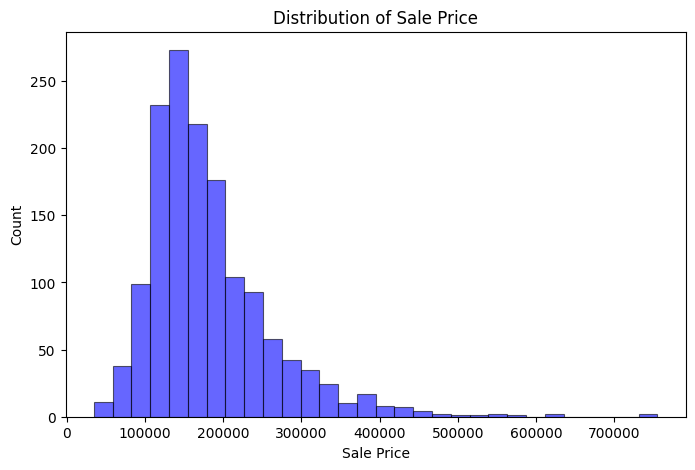

In [15]:
# Distribution of target variable

plt.figure(figsize=(8,5))
plt.hist(df['SalePrice'],bins=30,edgecolor="black",linewidth=0.8,color='blue',alpha=0.6)
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.title("Distribution of Sale Price")
plt.show()

In [16]:
# I have numeric columns in 'numeric_columns' variable and categorial columns in 'categorial_cols' variable

print(len(numeric_columns))
print(len(categorial_cols))

38
43


In [17]:
# Now let's plot a correlation matrix to find which Numeric columns affect the Sale Price of House

corr=df.corr(numeric_only=True)


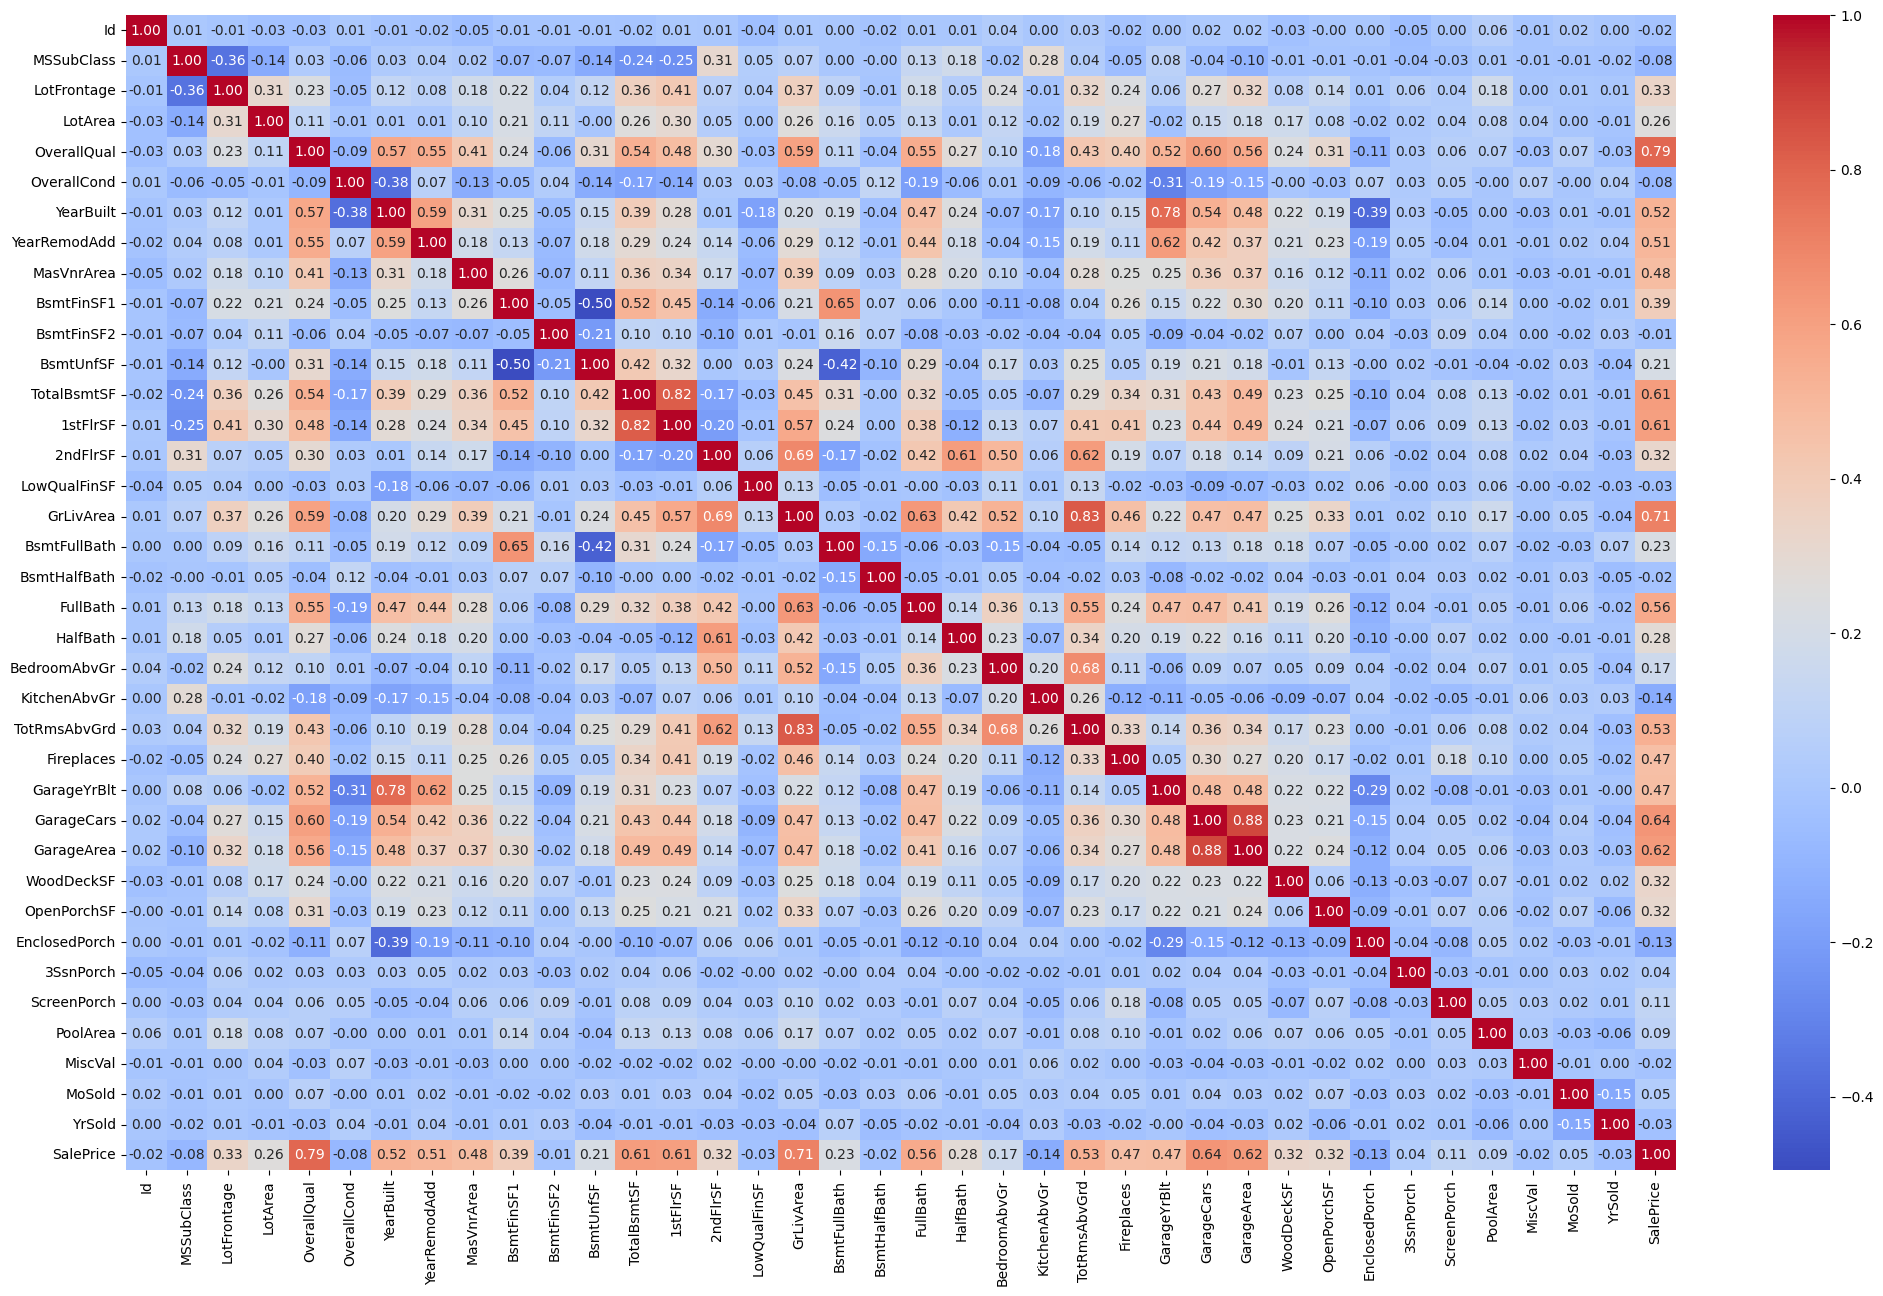

In [18]:
import seaborn as sns

plt.figure(figsize=(25,15))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.show()

### As there are lots of features out there we cannot find the correlation of features easily so will list the features correlation with our target variable that is Sale Price

In [19]:
corr['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.475241
GarageYrBlt      0.470177
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.334901
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

### From the list we will take the features that are highly correlated with Sale Price either positively or negatively

In [20]:
top_features=['SalePrice',
              'OverallQual',
              'GrLivArea',
              'GarageCars',
              'GarageArea',
              'TotalBsmtSF',
              '1stFlrSF'
             ]


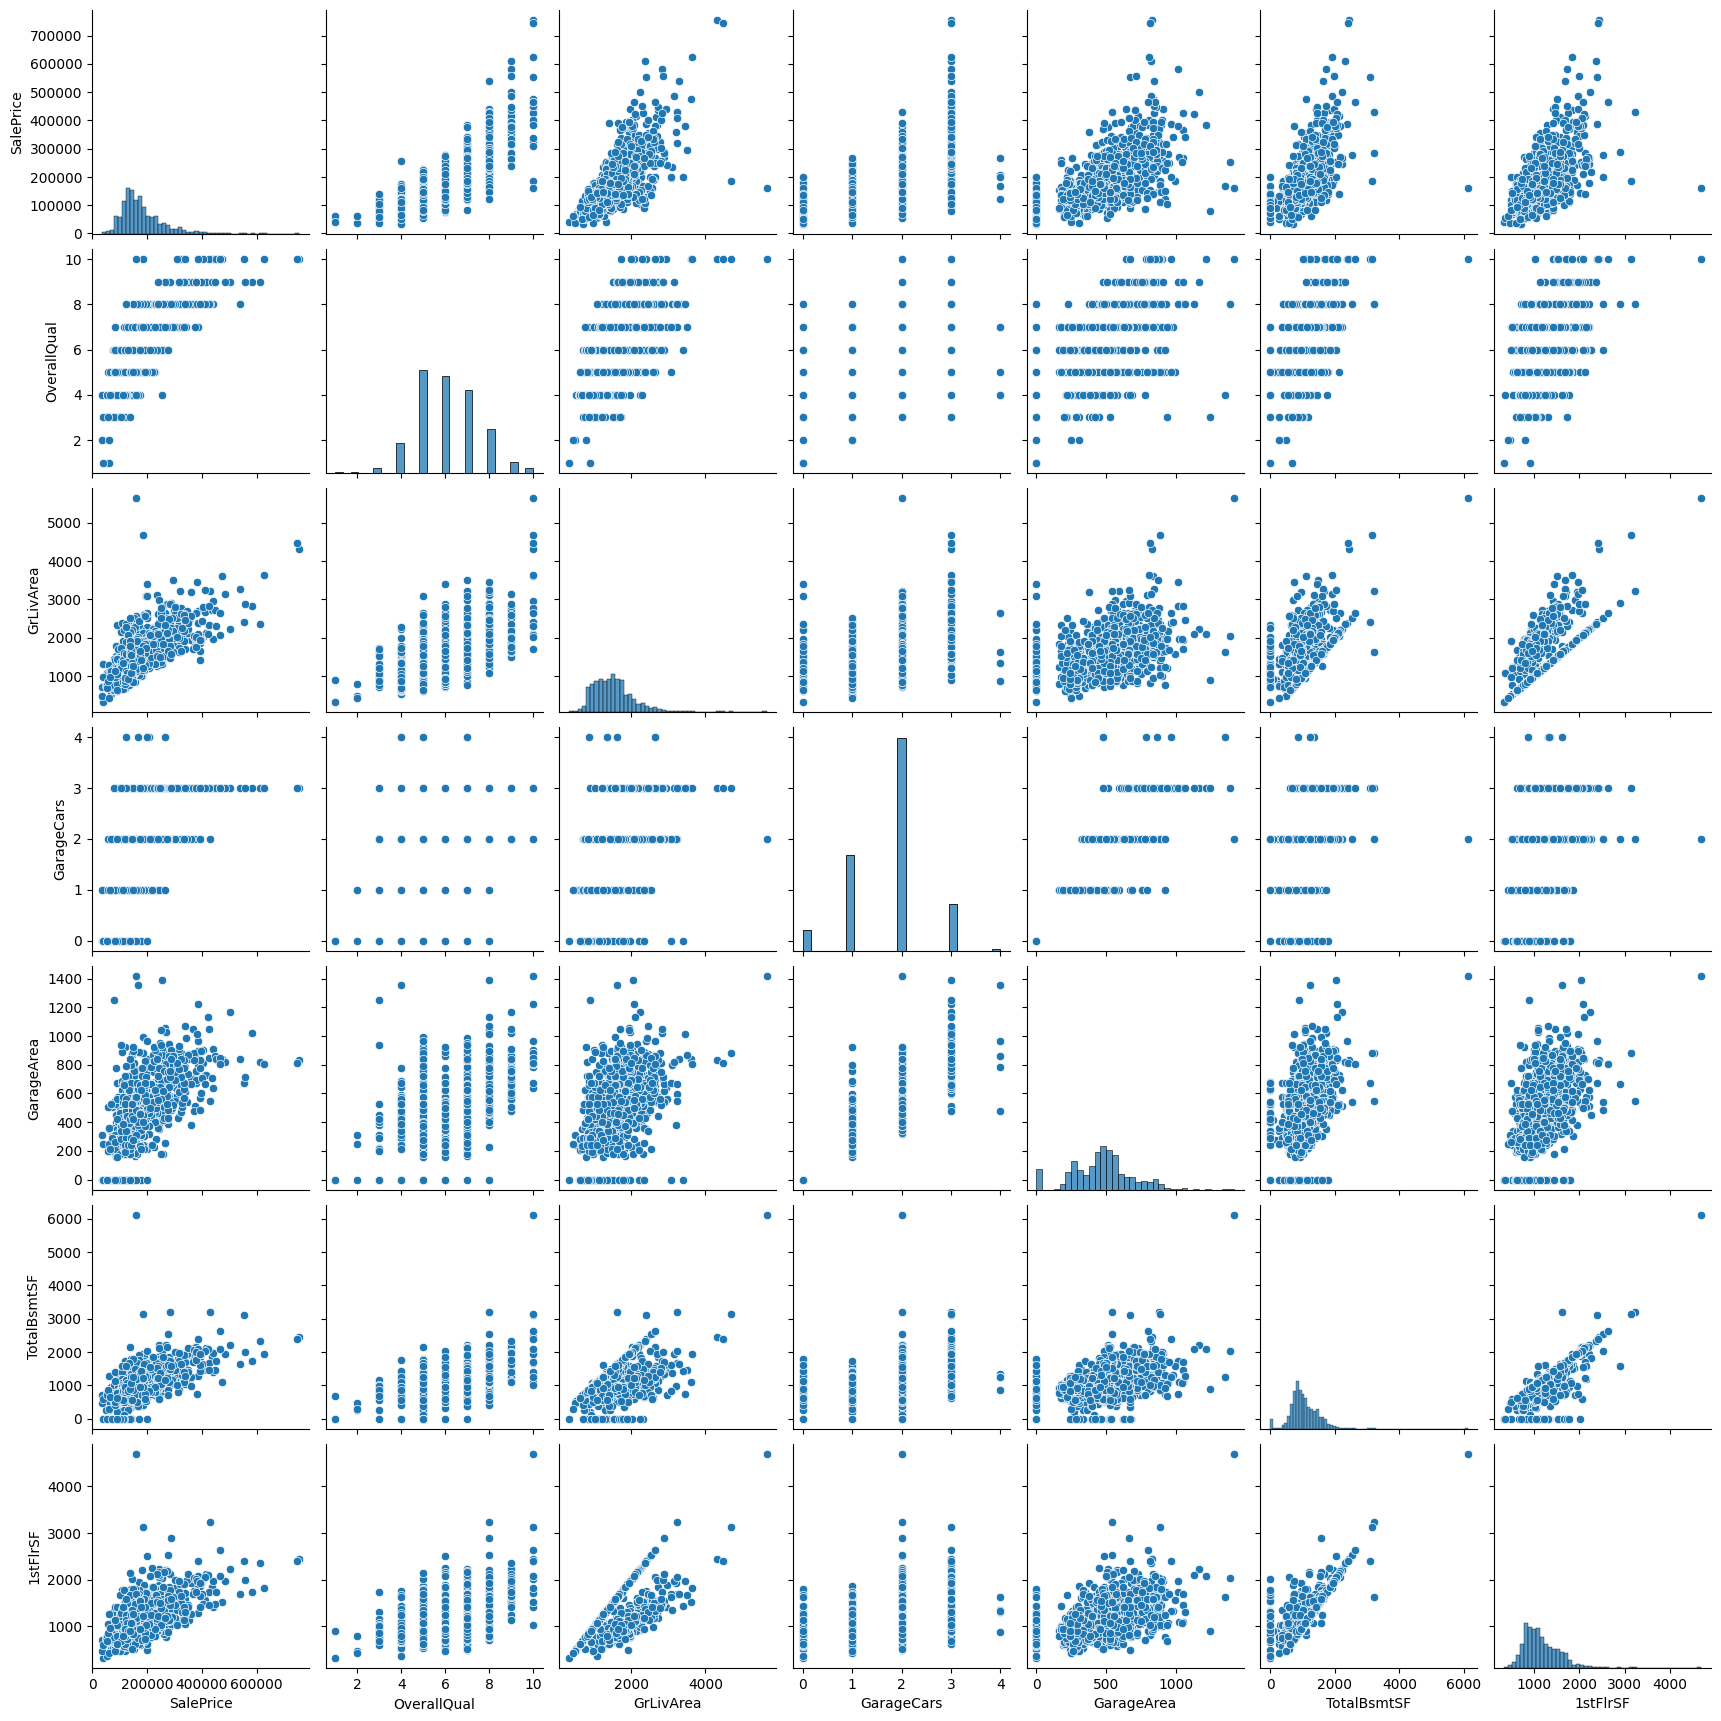

In [21]:
sns.pairplot(df[top_features])

### Its Still difficult to find a detail correlation so will individually plot the scatter plot of top_features vs SalePrice

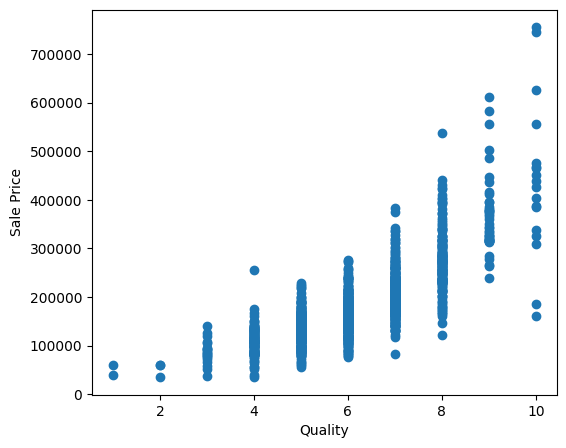

In [22]:
plt.figure(figsize=(6,5))

plt.scatter(df["OverallQual"], df["SalePrice"])

plt.xlabel("Quality")

plt.ylabel("Sale Price")

plt.show()

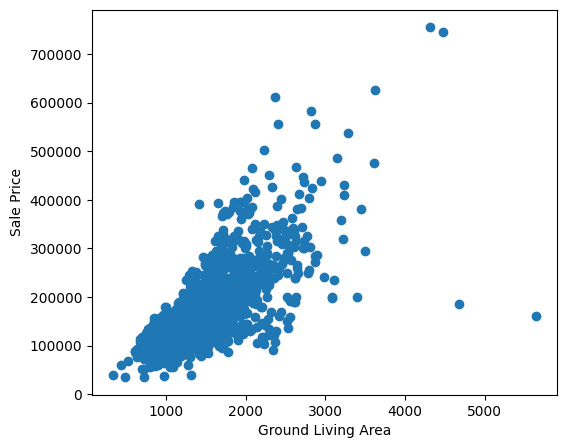

In [23]:
plt.figure(figsize=(6,5))

plt.scatter(df["GrLivArea"], df["SalePrice"])

plt.xlabel("Ground Living Area")

plt.ylabel("Sale Price")

plt.show()

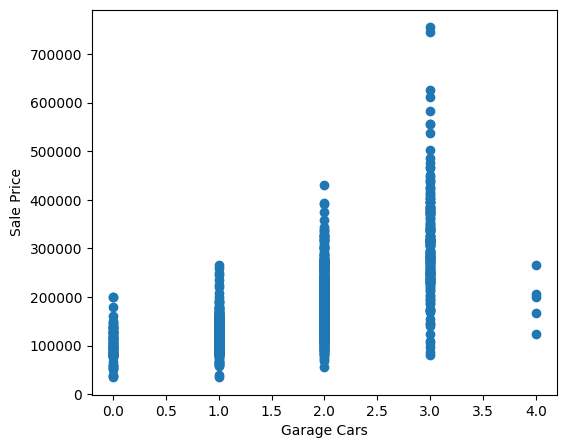

In [24]:
plt.figure(figsize=(6,5))

plt.scatter(df["GarageCars"], df["SalePrice"])

plt.xlabel("Garage Cars")

plt.ylabel("Sale Price")

plt.show()

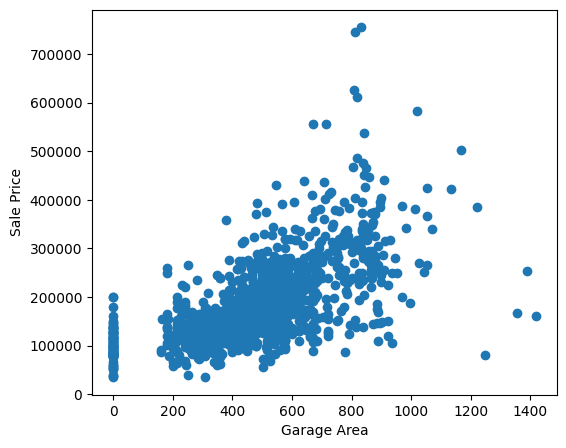

In [25]:
plt.figure(figsize=(6,5))

plt.scatter(df["GarageArea"], df["SalePrice"])

plt.xlabel("Garage Area")

plt.ylabel("Sale Price")

plt.show()

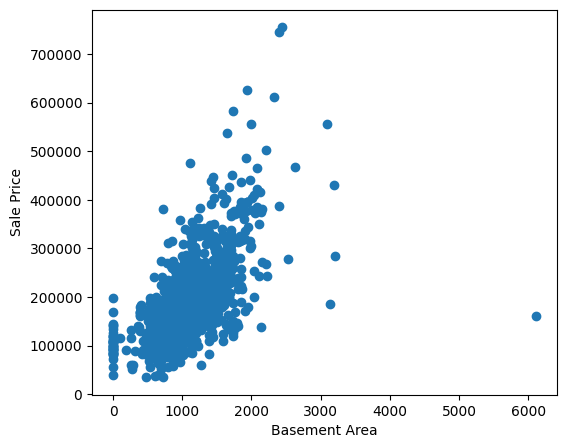

In [26]:
plt.figure(figsize=(6,5))

plt.scatter(df["TotalBsmtSF"], df["SalePrice"])

plt.xlabel("Basement Area")

plt.ylabel("Sale Price")

plt.show()

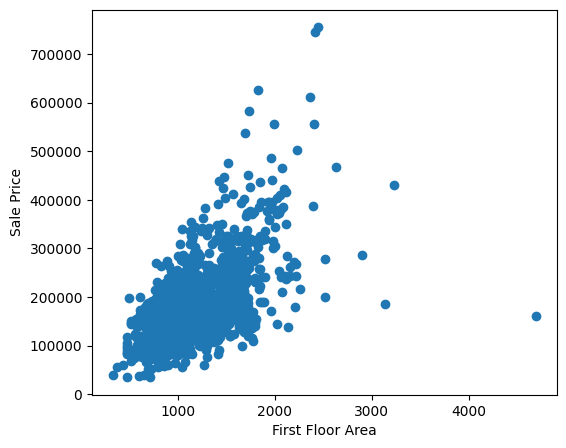

In [27]:
plt.figure(figsize=(6,5))

plt.scatter(df["1stFlrSF"], df["SalePrice"])

plt.xlabel("First Floor Area")

plt.ylabel("Sale Price")

plt.show()

### Now its time to find the categorial variables that will actually affect the SalePrice

In [28]:
print(categorial_cols)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [29]:
imp_cat=['MSZoning',
         'Street',
         'Neighborhood',
         'HouseStyle',
         'ExterQual',
         'BsmtQual',
         'CentralAir',
         'KitchenQual',
         'GarageQual',
         'SaleCondition'
        ]

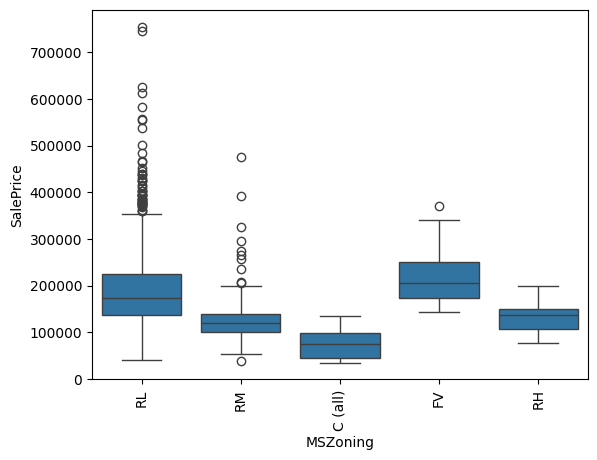

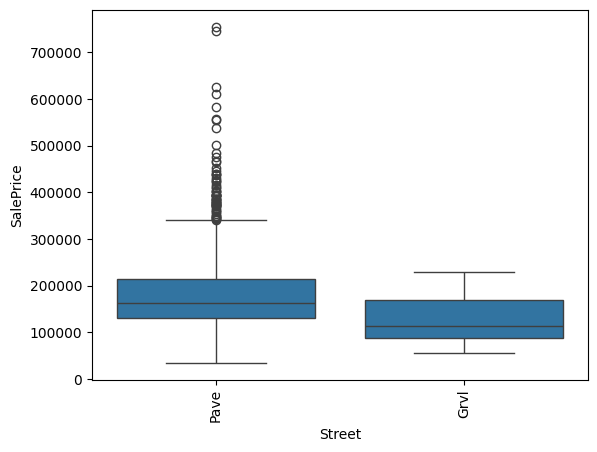

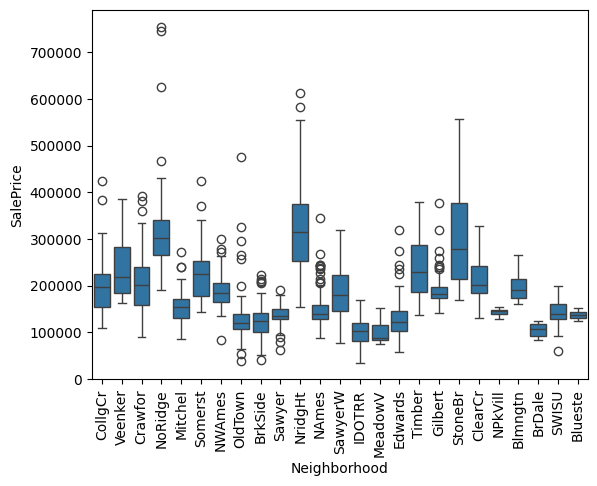

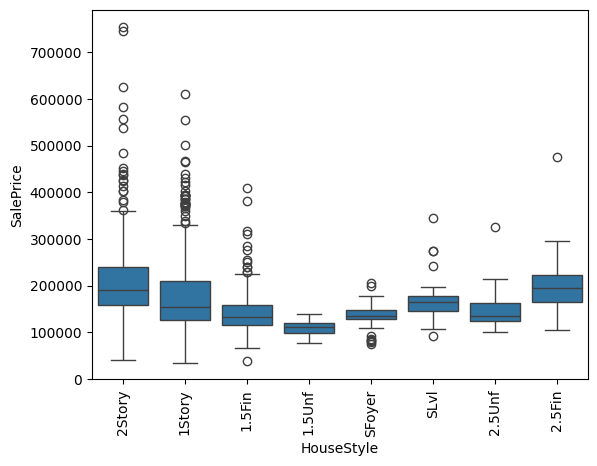

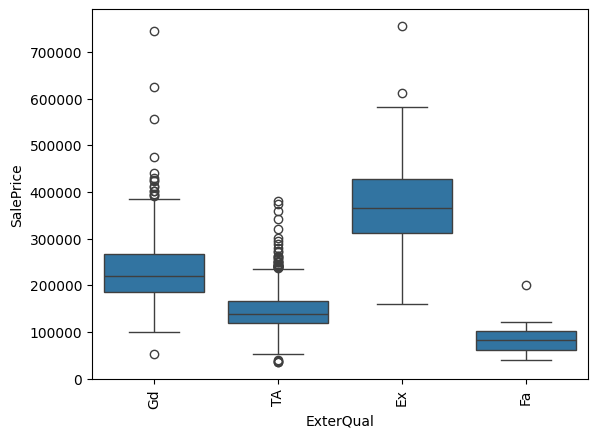

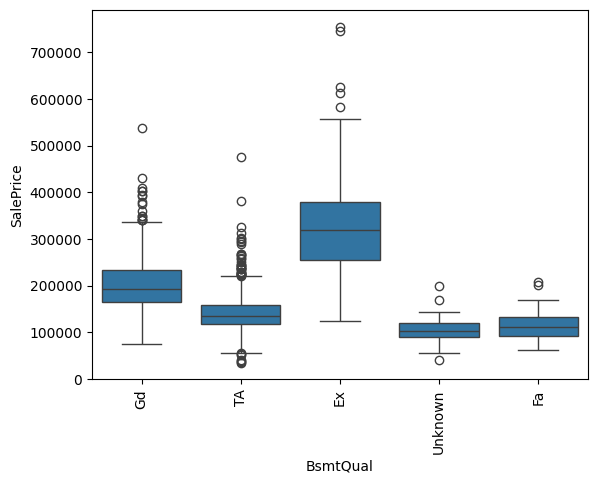

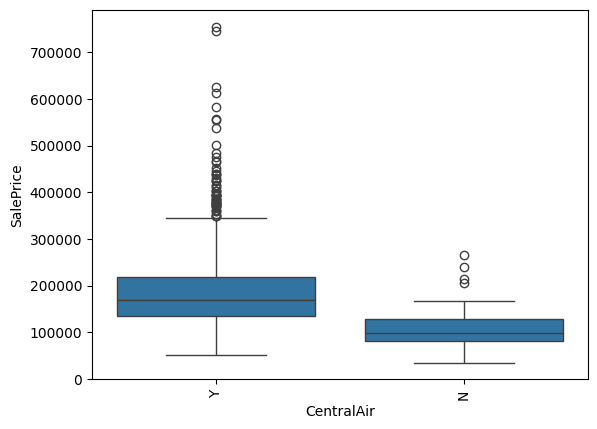

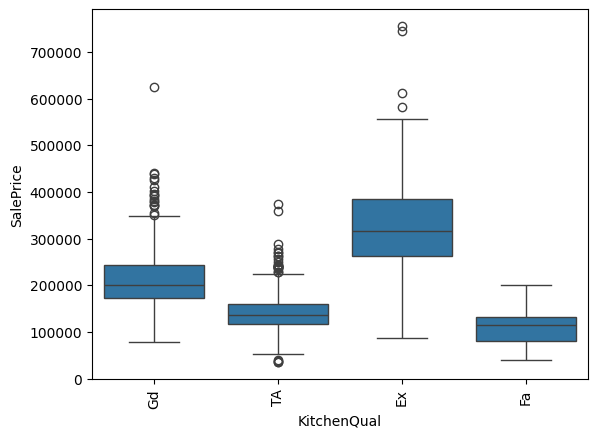

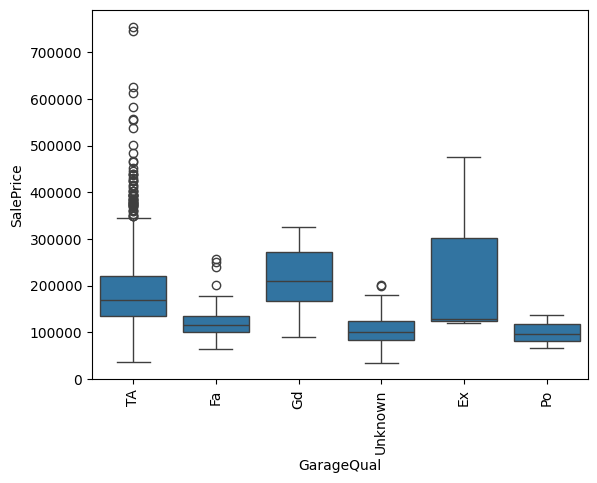

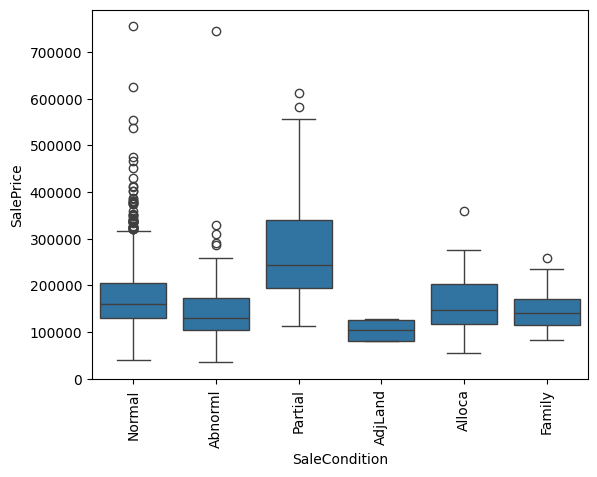

In [30]:
for feature in imp_cat:
    sns.boxplot(x=feature,y="SalePrice",data=df)
    plt.xticks(rotation=90)
    plt.show()


### Feature : MSZoning
### Here we can see that the box plot for different values show different Median which indicatess that the feature affects the Target variable (SalePrice).
### So will keep MSZoning
###
### Feature : Street 
### It does not show much variation.
### Highest median SalePrice: Pave (160k)
### lowest median SalePrice : Grvl (110k)
###
### Feature : Neighborhood
### There's a lot of variation of saleprice based on Neighborhood.
### Nridght shows highest Median SalePrice around 310k and MeadowV shows lowest Median SalePrice around 80k.Keep this feature also.
###
### Feature : HouseStyle
### It also doesn't show much variation
### Although different house styles exist,
### the distributions overlap considerably.
### It may still contribute after encoding, but it is probably less influential than Neighborhood or OverallQual.

### Highest median SalePrice: 2story and 2.5fin (190k)
### lowest median SalePrice : 1.5Unf (110k)
###
### Feature : ExterQual
### It shows variation 
### Highest average SalePrice: Ex (380k)
### lowest average SalePrice : Fa (90k)
### Also it has ordering so it can contribute well.
###
### Feature : BsmtQual
### It shows variation 
### Highest average SalePrice: Ex (310k)
### lowest average SalePrice : unknown(110k), Fa (120k)
###
### Feature : CentralAir
### It does not show much variation although it has two values Yes or No which can contribute to the prediction.
### Highest average SalePrice: Yes (170k)
### lowest average SalePrice : No (110k)
###
### Feature : KitchenQual
### It shows variation 
### Highest average SalePrice: Ex (320k)
### lowest average SalePrice : Fa (110k)
###
### Feature : GarageQual
### It shows moderate variation 
### Highest average SalePrice: Gd (210k)
### lowest average SalePrice : Po (100k)
###
### Feature : SaleCondition
### It shows moderate variation 
### Highest average SalePrice: Partial (230k)
### lowest average SalePrice : AdjLand (110k)




In [31]:
from scipy.stats import f_oneway

In [32]:
anova_results={}  # It is a dictionary to store results
for feature in imp_cat:
    # grouping saleprice values with the groups of the feature
    groups=[
        group["SalePrice"].values
        for _, group in df.groupby(feature)  
    ]
    f_statistic,p_value=f_oneway(*groups) # * is used as unpacked operator here
    anova_results[feature]={
            "F-statistic":f_statistic,
            "P-Value":p_value
    }

anova_df=pd.DataFrame(anova_results).T   # Transforming Dictionary to dataframe so that it is viewed properly
anova_df=anova_df.sort_values(by="P-Value")
print(anova_df)

               F-statistic        P-Value
Neighborhood     71.784865  1.558600e-225
ExterQual       443.334831  1.439551e-204
BsmtQual        316.148635  8.158548e-196
KitchenQual     407.806352  3.032213e-192
SaleCondition    45.578428   7.988268e-44
MSZoning         43.840282   8.817634e-35
HouseStyle       19.595001   3.376777e-25
GarageQual       25.776093   5.388762e-25
CentralAir       98.305344   1.809506e-22
Street            2.459290   1.170486e-01


### looking at p-value and f-statistic values we get to know that all features in imp_cat are having p-values < 0.005 except street 
### So all these features are very significant 
### But also small f-statistic value of Street suggests that it can still contribute to the prediction

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
OneHotEncoder,
OrdinalEncoder,
StandardScaler
)

In [34]:
X=df.drop("SalePrice",axis=1)
y=df["SalePrice"]

X.drop("Id",axis=1)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [35]:
numeric_features=X_train.select_dtypes(include=["int64","float64"]).columns.tolist()

nominal_features = [
    "MSZoning",
    "Street",
    "Neighborhood",
    "HouseStyle",
    "CentralAir",
    "SaleCondition"
]

ordinal_features = [
    "ExterQual",
    "BsmtQual",
    "KitchenQual",
    "GarageQual"
]

In [36]:
quality_order=[
    "Unknown",
    "Po",
    "Fa",
    "TA",
    "Gd",
    "Ex"
]


In [37]:
ordinal_encoder = OrdinalEncoder(
    categories=[
        quality_order,
        quality_order,
        quality_order,
        quality_order
    ]
)

onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    drop="first"
)

scaler=StandardScaler()

In [38]:
preprocessor=ColumnTransformer(
    transformers=[
        (
            "num",
            scaler,
            numeric_features
        ),
        (
            "nominal",
            onehot_encoder,
            nominal_features
        ),
        (
            "ordinal",
            ordinal_encoder,
            ordinal_features
        )
    ],
)

In [39]:
linear_pipeline=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",LinearRegression())
    ]
)

In [40]:
linear_pipeline.fit(X_train,y_train)

linear_predictions=linear_pipeline.predict(X_test)

In [41]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [42]:
mae = mean_absolute_error(y_test,linear_predictions)
mse = mean_squared_error(y_test,linear_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,linear_predictions)

print("Linear Regression")

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 :", r2)

Linear Regression
MAE : 19411.23597774682
MSE : 1065026686.1643823
RMSE : 32634.74660793894
R2 : 0.8611497532964832


In [43]:
from sklearn.ensemble import RandomForestRegressor

In [44]:
rf_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        (

            "model",

            RandomForestRegressor(

                n_estimators=100,

                random_state=42

            )

        )

    ]

)

In [45]:
rf_pipeline.fit(X_train,y_train)
rf_predictions=rf_pipeline.predict(X_test)


In [46]:
rf_mae = mean_absolute_error(y_test,rf_predictions)
rf_mse = mean_squared_error(y_test,rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test,rf_predictions)

print("Random Forest")

print("MAE :", rf_mae)

print("MSE :", rf_mse)

print("RMSE :", rf_rmse)

print("R2 :", rf_r2)

Random Forest
MAE : 17516.75773972603
MSE : 837369227.33282
RMSE : 28937.332761206933
R2 : 0.8908300371178215


In [47]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "MSE": [mse, rf_mse],
    "RMSE": [rmse, rf_rmse],
    "R² Score": [r2, rf_r2],
    "Variance Explained (%)": [r2 * 100, rf_r2 * 100]
})

print(comparison)

               Model           MAE           MSE          RMSE  R² Score  \
0  Linear Regression  19411.235978  1.065027e+09  32634.746608   0.86115   
1      Random Forest  17516.757740  8.373692e+08  28937.332761   0.89083   

   Variance Explained (%)  
0               86.114975  
1               89.083004  


In [48]:
top_numeric = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF'
]

imp_cat = [
    'MSZoning',
    'Street',
    'Neighborhood',
    'HouseStyle',
    'ExterQual',
    'BsmtQual',
    'CentralAir',
    'KitchenQual',
    'GarageQual',
    'SaleCondition'
]

In [49]:
selected_features=top_numeric+imp_cat
print(selected_features)

['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'MSZoning', 'Street', 'Neighborhood', 'HouseStyle', 'ExterQual', 'BsmtQual', 'CentralAir', 'KitchenQual', 'GarageQual', 'SaleCondition']


In [50]:
X=df[selected_features]
y=df["SalePrice"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [51]:
numeric_features = top_numeric
ordinal_features = [
    "ExterQual",
    "BsmtQual",
    "KitchenQual",
    "GarageQual"
]
nominal_features = list(
    set(imp_cat) - set(ordinal_features)
)

In [52]:
quality_order = [
    "Unknown",
    "Po",
    "Fa",
    "TA",
    "Gd",
    "Ex"
]

ordinal_encoder = OrdinalEncoder(
    categories=[quality_order] * len(ordinal_features)
)

onehot_encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore"
)

scaler = StandardScaler()

In [53]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            scaler,
            numeric_features
        ),

        (
            "nominal",
            onehot_encoder,
            nominal_features
        ),

        (
            "ordinal",
            ordinal_encoder,
            ordinal_features
        )

    ]

)

In [54]:
linear_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", LinearRegression())

    ]

)

linear_pipeline.fit(X_train, y_train)
linear_predictions = linear_pipeline.predict(X_test)

In [55]:
mae = mean_absolute_error(y_test, linear_predictions)

mse = mean_squared_error(y_test, linear_predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, linear_predictions)

print(mae)
print(rmse)
print(r2)

21140.783994567973
34942.965468205744
0.8408137016952255


In [56]:
rf_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        (
            "model",

            RandomForestRegressor(
                random_state=42,
                n_estimators=100
            )

        )

    ]

)

rf_pipeline.fit(X_train, y_train)
rf_predictions = rf_pipeline.predict(X_test)

In [57]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "MSE": [mse, rf_mse],
    "RMSE": [rmse, rf_rmse],
    "R² Score": [r2, rf_r2],
    "Variance Explained (%)": [r2 * 100, rf_r2 * 100]
})

print(comparison)

               Model           MAE           MSE          RMSE  R² Score  \
0  Linear Regression  21140.783995  1.221011e+09  34942.965468  0.840814   
1      Random Forest  17516.757740  8.373692e+08  28937.332761  0.890830   

   Variance Explained (%)  
0               84.081370  
1               89.083004  


In [58]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "MSE": [mse, rf_mse],
    "RMSE": [rmse, rf_rmse],
    "R² Score": [r2, rf_r2],
    "Variance Explained (%)": [r2 * 100, rf_r2 * 100]
})

print(comparison)

               Model           MAE           MSE          RMSE  R² Score  \
0  Linear Regression  21140.783995  1.221011e+09  34942.965468  0.840814   
1      Random Forest  17516.757740  8.373692e+08  28937.332761  0.890830   

   Variance Explained (%)  
0               84.081370  
1               89.083004  


In [59]:
import joblib

joblib.dump(rf_pipeline, "house_price_model.pkl")

['house_price_model.pkl']